# E27 · Sparse regression: horseshoe, regularised horseshoe, spike-and-slab

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Prostate cancer (Stamey et al. 1989; 97 men, 8 predictors, the *Elements of Statistical Learning* train/test split) and the LARS diabetes data (Efron et al. 2004; 442 patients, 10 baseline variables expanded to 64 with all interactions and squares, fitted on 120 patients) |
| **You will learn** | What a shrinkage prior does, read through the shrinkage factor $\kappa$ · Normal (ridge), Laplace (Bayesian lasso), horseshoe, regularised horseshoe · why the Bayesian lasso's *posterior* is not sparse · choosing the global scale from a guess $p_0$ and checking the implied prior on the effective number of non-zero coefficients $m_\text{eff}$ · the horseshoe's divergences and the three things that remove them · spike-and-slab by marginalising the inclusion indicators - and what NUTS cannot do with it, checked against exact enumeration · posterior inclusion probabilities and why correlated predictors make them misleading · projection predictive variable selection in NumPy · lasso with cross-validation in NumPy · held-out predictive comparison |

Most regressions with many candidate predictors carry a belief that is not written down in a
Normal prior: *most of these variables do nothing, a few do a lot*. A Normal prior cannot say
that - it shrinks every coefficient by the same factor. Sparse priors can: they pull noise
coefficients hard towards zero while leaving large signals almost alone.

This notebook is the dedicated treatment of those priors. E19 already uses a regularised
horseshoe inside neighbourhood selection for a graph (and shows how the horseshoe breaks when
it is placed on a precision matrix); here we look at the prior itself: what it assumes, how to
set its one important knob, why the plain version makes NUTS diverge, how it compares with
the discrete spike-and-slab that many people have in mind when they say "variable
selection", and how to go from a posterior to an actual choice of variables.

Two datasets. **Prostate** (8 predictors) is small enough to enumerate every one of the 256
submodels exactly, so we can check what NUTS gets right. **Diabetes** (64 predictors, 120
training patients, 322 held out) is where the shrinkage is needed, the geometry gets hard,
and the predictors are strongly correlated.

In [1]:
import itertools
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from pymc_extras.marginal import marginalize
from scipy import stats
from scipy.special import betaln, logsumexp

from pymc_challenges import data

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many small fits: no banner for each
BLUE, ORANGE, AQUA, GREY, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8e5bd0"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def fit(model, label, target_accept=0.8, **kw):
    """Sample with nutpie and print the diagnostics we care about in one line."""
    t0 = time.time()
    with model:
        idata = pm.sample(target_accept=target_accept, random_seed=RANDOM_SEED, progressbar=False, **kw)
    names = [v for v in ["beta", "tau", "sigma"] if v in idata.posterior]
    s = az.summary(idata, var_names=names)
    div = int(idata.sample_stats["diverging"].sum())
    print(f"{label:<38} {time.time() - t0:5.1f} s  divergences {div:4d}  max r_hat {s['r_hat'].max():.3f}  "
          f"min ess_bulk {s['ess_bulk'].min():5.0f}")
    return idata


def draws(idata, var):
    """Posterior draws as a (sample, ...) NumPy array."""
    return idata.posterior[var].stack(sample=("chain", "draw")).transpose("sample", ...).to_numpy()

PyMC 6.3.2, ArviZ 1.3.0


## 1 · Prostate: eight predictors, 67 training men

The response is log prostate-specific antigen (`lpsa`), measured before surgery in 97 men;
the predictors are log cancer volume, log prostate weight, age, log benign prostatic
hyperplasia amount, seminal vesicle invasion (0/1), log capsular penetration, Gleason score
and the percentage of Gleason scores 4 or 5. The data come with a fixed split into 67
training and 30 test men, which we keep. Everything is standardised with the training means
and sds, so every coefficient is "sd of log PSA per sd of predictor" and one prior scale fits
all of them.

In [2]:
data.describe("prostate")
pr = data.load("prostate")
PR_NAMES = pr.columns[:8].tolist()
is_train = pr["train"].eq("T").to_numpy()
Xraw, yraw = pr[PR_NAMES].to_numpy(float), pr["lpsa"].to_numpy(float)
x_mu, x_sd = Xraw[is_train].mean(0), Xraw[is_train].std(0)
y_mu, y_sd = yraw[is_train].mean(), yraw[is_train].std()
Xp, yp = (Xraw - x_mu) / x_sd, (yraw - y_mu) / y_sd
Xp_tr, yp_tr, Xp_te, yp_te = Xp[is_train], yp[is_train], Xp[~is_train], yp[~is_train]
n_p, P_p = Xp_tr.shape

b_ols = np.linalg.lstsq(np.c_[np.ones(n_p), Xp_tr], yp_tr, rcond=None)[0][1:]
print(f"{n_p} training men, {len(yp_te)} test men, {P_p} predictors")
pd.DataFrame(np.corrcoef(Xp_tr.T), index=PR_NAMES, columns=PR_NAMES).round(2)

prostate: 97 men: log PSA (lpsa) and 8 clinical predictors (log cancer volume lcavol, log prostate weight lweight, age, lbph, seminal vesicle invasion svi, lcp, gleason, pgg45), plus the book's train/test flag (67 T / 30 F).
  source: Stamey et al. (1989, J. Urology 141:1076), prostate cancer before radical prostatectomy; the benchmark of Hastie, Tibshirani & Friedman, The Elements of Statistical Learning (2009), ch. 3.
  url:    https://hastie.su.domains/ElemStatLearn/datasets/prostate.data
67 training men, 30 test men, 8 predictors


,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45
lcavol,1.00,0.30,0.29,0.06,0.59,0.69,0.43,0.48
lweight,0.30,1.00,0.32,0.44,0.18,0.16,0.02,0.07
age,0.29,0.32,1.00,0.29,0.13,0.17,0.37,0.28
lbph,0.06,0.44,0.29,1.00,-0.14,-0.09,0.03,-0.03
svi,0.59,0.18,0.13,-0.14,1.00,0.67,0.31,0.48
lcp,0.69,0.16,0.17,-0.09,0.67,1.00,0.48,0.66
gleason,0.43,0.02,0.37,0.03,0.31,0.48,1.00,0.76
pgg45,0.48,0.07,0.28,-0.03,0.48,0.66,0.76,1.00


Moderate correlations: cancer volume goes with capsular penetration (0.69) and seminal
vesicle invasion (0.59), and the two Gleason variables with each other (0.76). Nothing
pathological - which is why this is the dataset for intuition.

## 2 · What a shrinkage prior does: the shrinkage factor $\kappa$

Write every prior in the family we care about as a **scale mixture of Normals**,

$$\beta_j \mid \lambda_j, \tau \sim \text{Normal}(0,\ \tau\lambda_j),$$

with a *global* scale $\tau$ shared by all coefficients and a *local* scale $\lambda_j$ for
each. For a Normal prior (ridge) $\lambda_j = 1$; for the Laplace (Bayesian lasso)
$\lambda_j^2 \sim \text{Exponential}$; for the **horseshoe** (Carvalho, Polson & Scott 2010)
$\lambda_j \sim \text{HalfCauchy}(1)$.

With standardised, roughly uncorrelated predictors the posterior mean of $\beta_j$ given the
scales is the least-squares estimate multiplied by $1 - \kappa_j$, where

$$\kappa_j = \frac{1}{1 + n\,\tau^2\lambda_j^2/\sigma^2} \in (0, 1)$$

is the **shrinkage factor**: $\kappa_j = 0$ leaves the coefficient alone, $\kappa_j = 1$
sets it to zero. The prior on $\lambda_j$ therefore *is* a prior on how much each coefficient
is shrunk. Here is that prior for the three families, at the global scale where
$n\tau^2/\sigma^2 = 1$.

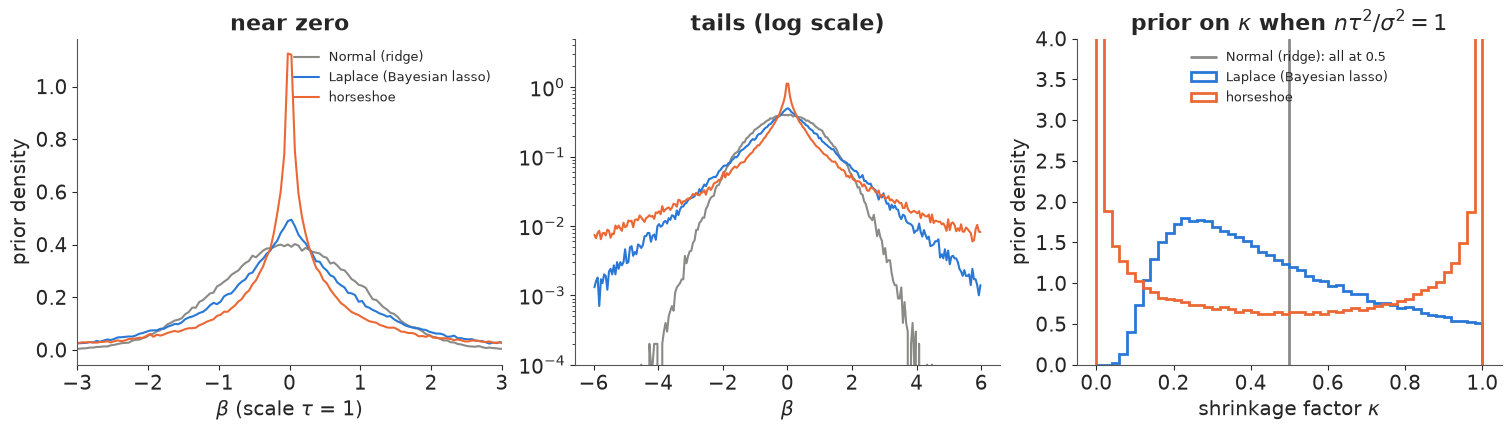

In [3]:
S = 200_000
lam = {
    "Normal (ridge)": np.ones(S),
    "Laplace (Bayesian lasso)": np.sqrt(rng.exponential(2.0, S)),     # lambda^2 ~ Exp(mean 2): Laplace(0, 1)
    "horseshoe": np.abs(stats.cauchy.rvs(size=S, random_state=rng)),
}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for (name, l), col in zip(lam.items(), [GREY, BLUE, ORANGE]):
    b = rng.normal(0, 1, S) * l
    h, e = np.histogram(b, bins=240, range=(-6, 6), density=True)
    axes[0].plot(0.5 * (e[1:] + e[:-1]), h, color=col, label=name)
    axes[1].plot(0.5 * (e[1:] + e[:-1]), h, color=col)
    kappa = 1 / (1 + l**2)
    if name.startswith("Normal"):
        axes[2].axvline(0.5, color=col, lw=2, label=f"{name}: all at 0.5")
    else:
        axes[2].hist(kappa, bins=50, range=(0, 1), density=True, histtype="step", lw=2, color=col, label=name)
axes[0].set(xlim=(-3, 3), xlabel=r"$\beta$ (scale $\tau$ = 1)", ylabel="prior density", title="near zero")
axes[1].set(yscale="log", ylim=(1e-4, 5), xlabel=r"$\beta$", title="tails (log scale)")
axes[2].set(xlabel=r"shrinkage factor $\kappa$", ylabel="prior density", ylim=(0, 4),
            title=r"prior on $\kappa$ when $n\tau^2/\sigma^2 = 1$")
axes[0].legend(fontsize=9)
axes[2].legend(fontsize=9, loc="upper center");

The right panel is the whole argument for the horseshoe. Its $\kappa$ prior is
$\text{Beta}(\tfrac12, \tfrac12)$: a U shape with mass piled at **both** ends, i.e. "each
coefficient is either shrunk almost completely or barely at all". The Laplace prior puts its
$\kappa$ mass in the middle and has no pole at $\kappa = 0$ - it shrinks large coefficients by
a fixed amount (the lasso's well-known bias) and, as we will see, never shrinks small ones
all the way. The Normal shrinks every coefficient by the *same* factor. The left panels say
the same thing in terms of $\beta$: the horseshoe has an infinitely tall spike at zero *and*
Cauchy tails.

## 3 · Three priors on the prostate data

All three models share an intercept, $\sigma \sim \text{HalfNormal}(1)$ and a global scale
learned from the data; they differ only in the local scales. All are written non-centred
($\beta_j = z_j\,\tau\lambda_j$ with $z_j \sim \text{Normal}(0, 1)$) except the Laplace, which
PyMC samples directly.

In [4]:
def sparse_lm(X, y, prior, names, tau0=1.0, slab_df=4.0, slab_scale=1.0, centred=False, slab=True):
    """Linear regression with standardised predictors and one of several coefficient priors."""
    n, P = X.shape
    with pm.Model(coords={"pred": names}) as model:
        a = pm.Normal("a", 0.0, 1.0)
        sigma = pm.HalfNormal("sigma", 1.0)
        if prior == "ridge":
            tau = pm.HalfNormal("tau", 1.0)
            beta = pm.Deterministic("beta", pm.Normal("z", 0.0, 1.0, dims="pred") * tau, dims="pred")
        elif prior == "lasso":
            tau = pm.HalfNormal("tau", 1.0)
            beta = pm.Laplace("beta", 0.0, tau, dims="pred")
        elif prior == "horseshoe":
            tau = pm.HalfCauchy("tau", tau0)
            lam = pm.HalfCauchy("lam", 1.0, dims="pred")
            if centred:
                beta = pm.Normal("beta", 0.0, tau * lam, dims="pred")
            else:
                beta = pm.Deterministic("beta", pm.Normal("z", 0.0, 1.0, dims="pred") * tau * lam, dims="pred")
        elif prior == "reg_horseshoe":
            # Piironen & Vehtari (2017): tau ~ HalfCauchy(tau0 * sigma), slab c^2 ~ InvGamma(nu/2, nu s^2/2)
            tau = pm.Deterministic("tau", pm.HalfCauchy("tau_raw", 1.0) * tau0 * sigma)
            lam = pm.HalfCauchy("lam", 1.0, dims="pred")
            if slab:
                c2 = pm.InverseGamma("c2", slab_df / 2, slab_df * slab_scale**2 / 2)
                lam_t = pt.sqrt(c2 * lam**2 / (c2 + tau**2 * lam**2))
            else:                                     # the p0-based global scale without the slab
                lam_t = lam
            beta = pm.Deterministic("beta", pm.Normal("z", 0.0, 1.0, dims="pred") * tau * lam_t, dims="pred")
        pm.Normal("y", a + pt.as_tensor(X) @ beta, sigma, observed=y)
    return model


fits_pr = {name: fit(sparse_lm(Xp_tr, yp_tr, name, PR_NAMES), f"prostate, {name}", target_accept=0.99)
           for name in ["ridge", "lasso", "horseshoe"]}

prostate, ridge                          1.8 s  divergences    0  max r_hat 1.006  min ess_bulk   709


prostate, lasso                          0.7 s  divergences    0  max r_hat 1.001  min ess_bulk  1964


prostate, horseshoe                      1.2 s  divergences   20  max r_hat 1.006  min ess_bulk  1031


All three at `target_accept=0.99`, because the horseshoe needs it and a fair comparison uses
the same settings. The coefficients side by side, with least squares as the unshrunk
reference:

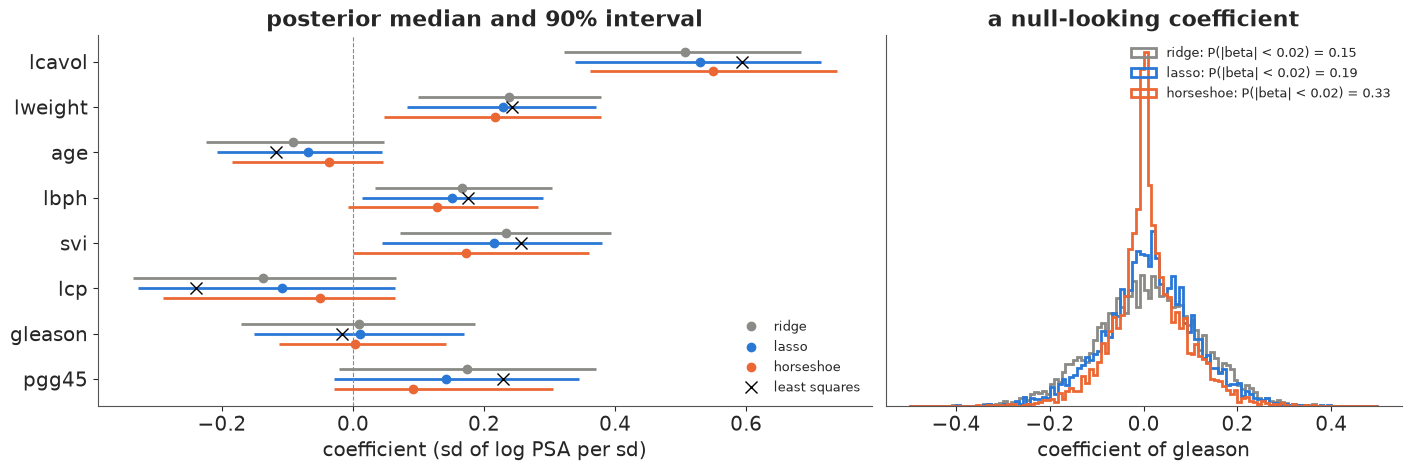

In [5]:
cols = {"ridge": GREY, "lasso": BLUE, "horseshoe": ORANGE}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
for k, (name, idata) in enumerate(fits_pr.items()):
    B = draws(idata, "beta")
    lo, med, hi = np.quantile(B, [0.05, 0.5, 0.95], axis=0)
    yy = np.arange(P_p) + 0.22 * (k - 1)
    ax.hlines(yy, lo, hi, color=cols[name], lw=2)
    ax.plot(med, yy, "o", color=cols[name], label=name)
ax.plot(b_ols, np.arange(P_p), "kx", ms=8, label="least squares")
ax.axvline(0, color=GREY, lw=0.8, ls="--")
ax.set(yticks=range(P_p), xlabel="coefficient (sd of log PSA per sd)", title="posterior median and 90% interval")
ax.set_yticklabels(PR_NAMES)
ax.invert_yaxis()
ax.legend(fontsize=9, loc="lower right")
ax = axes[1]
j = PR_NAMES.index("gleason")
for name in ["ridge", "lasso", "horseshoe"]:
    b = draws(fits_pr[name], "beta")[:, j]
    ax.hist(b, bins=120, range=(-0.5, 0.5), density=True, histtype="step", lw=2, color=cols[name],
            label=f"{name}: P(|beta| < 0.02) = {np.mean(np.abs(b) < 0.02):.2f}")
ax.set(xlabel="coefficient of gleason", yticks=[], title="a null-looking coefficient")
ax.legend(fontsize=9);

In [6]:
tab = pd.DataFrame({"least squares": b_ols} | {name: np.median(draws(i, "beta"), 0) for name, i in fits_pr.items()},
                   index=PR_NAMES)
tab.loc["global scale tau (median)"] = [np.nan] + [np.median(draws(i, "tau")) for i in fits_pr.values()]


def rmse_test(a, B):
    return np.sqrt(np.mean(((a + B @ Xp_te.T).mean(0) - yp_te) ** 2)) * y_sd   # log PSA units


a_ols = yp_tr.mean() - Xp_tr.mean(0) @ b_ols
tab.loc["test RMSE, 30 men"] = [rmse_test(np.array([a_ols]), b_ols[None, :])] + [
    rmse_test(draws(i, "a")[:, None], draws(i, "beta")) for i in fits_pr.values()]
tab.round(3)

,least squares,ridge,lasso,horseshoe
lcavol,0.593,0.507,0.529,0.550
lweight,0.242,0.239,0.228,0.217
age,-0.118,-0.091,-0.069,-0.037
lbph,0.176,0.166,0.151,0.128
svi,0.256,0.234,0.215,0.173
lcp,-0.239,-0.137,-0.109,-0.051
gleason,-0.017,0.009,0.011,0.004
pgg45,0.230,0.174,0.141,0.091
global scale tau (median),NaN,0.284,0.235,0.214
"test RMSE, 30 men",0.722,0.705,0.692,0.677


All three agree on the big picture - cancer volume dominates, prostate weight, seminal
vesicle invasion and `lbph` push log PSA up, Gleason score adds nothing once the rest is
known. On the 30 test men the horseshoe predicts best and least squares worst (RMSE 0.68
against 0.72 log-PSA units), with ridge and lasso in between, but 30 men are too few to make
much of differences that size. Where the priors really differ is in *how* they shrink:

- **Ridge** has one scale for everything, so the strongest coefficient pays too: `lcavol`
  loses about 15% (0.59 to 0.51), while the weak `pgg45` keeps three quarters of its size.
- **Horseshoe** leaves the strong coefficient almost alone (`lcavol` 0.55) and pulls the weak,
  uncertain ones much harder: `lcp` from -0.24 to -0.05, `age` from -0.12 to -0.04, `pgg45`
  from 0.23 to 0.09. That is the U-shaped $\kappa$ prior at work.
- **Laplace** sits in between on every row except the null `gleason`.

One warning sign already: even at `target_accept=0.99` the horseshoe has about 20
divergent transitions in 4000 draws (the other two have none). With 8 well-determined
coefficients this is a minor blemish; section 7 shows what it grows into with 64.

### Why the Bayesian lasso's posterior is not sparse

The lasso *estimate* is the posterior **mode** under a Laplace prior, and the mode of a
Laplace posterior sits exactly at zero for weak coefficients - that is where the lasso's
zeros come from. But the posterior **mass** at exactly zero is zero, and the mass *near*
zero is not much larger than under a Normal prior: the Laplace spike at zero is a kink, not
a pole. Any summary that uses the whole posterior (mean, median, interval, prediction)
is therefore not sparse. In the right panel the posterior probability that the Gleason
coefficient is within 0.02 of zero is 0.15 under ridge, 0.19 under the Laplace and 0.33 under
the horseshoe: the horseshoe's pole at zero is what produces real posterior mass there. And
the Laplace's single rate $\tau$ has two jobs at once - shrinking the noise and leaving the
signal alone - which it cannot both do: compared with the horseshoe it pulls `lcavol` down
further (0.53 against 0.55) while leaving more of the weak `pgg45` (0.14 against 0.09).

## 4 · Spike-and-slab: the prior people have in mind, and what NUTS can do with it

The "real" variable-selection prior has a discrete indicator per coefficient:

$$\gamma_j \sim \text{Bernoulli}(\pi), \qquad \beta_j \mid \gamma_j = 1 \sim \text{Normal}(0, \sigma v), \qquad \beta_j \mid \gamma_j = 0 = 0 \text{ exactly}.$$

NUTS cannot sample the $\gamma_j$ (they are discrete), and it cannot marginalise them either,
because with a point mass at zero the likelihood depends on the whole vector $\gamma$ at
once: summing it out means summing over all $2^P$ subsets. For $P = 8$ that is 256 models,
and with a conjugate prior each has a closed-form marginal likelihood. So for prostate we
can compute the **exact** posterior inclusion probabilities (PIPs) in a few lines of NumPy:
$\sigma^2 \sim \text{InvGamma}(1, 1)$, slab variance $v = 1$ (in units of $\sigma$), a flat
intercept (handled by centring) and $\pi \sim \text{Beta}(1, 1)$, which puts equal prior
mass on each model *size*.

In [7]:
V_SLAB, A0, B0 = 1.0, 1.0, 1.0
MODELS = np.array(list(itertools.product([0, 1], repeat=P_p)), dtype=bool)
yc = yp_tr - yp_tr.mean()
log_post = np.empty(len(MODELS))
for m, g in enumerate(MODELS):
    Xc = Xp_tr[:, g] - Xp_tr[:, g].mean(0)
    Sig = np.eye(n_p) + V_SLAB * Xc @ Xc.T              # y | gamma, sigma^2 ~ N(0, sigma^2 Sig)
    _, logdet = np.linalg.slogdet(Sig)
    quad = yc @ np.linalg.solve(Sig, yc)
    k = g.sum()
    log_post[m] = (-0.5 * logdet - (A0 + (n_p - 1) / 2) * np.log(B0 + quad / 2)   # sigma^2 integrated out
                   + betaln(1 + k, 1 + P_p - k))                                  # pi integrated out
w_models = np.exp(log_post - logsumexp(log_post))
pip_exact = w_models @ MODELS
for m in np.argsort(-w_models)[:5]:
    print(f"P(model) = {w_models[m]:.3f}: {', '.join(np.array(PR_NAMES)[MODELS[m]])}")

P(model) = 0.140: lcavol, lweight
P(model) = 0.077: lcavol, lweight, svi
P(model) = 0.066: lcavol, lweight, age, lbph, svi, lcp, gleason, pgg45
P(model) = 0.058: lcavol, lweight, lbph, svi
P(model) = 0.043: lcavol, lweight, pgg45


For NUTS we replace the point mass by a narrow Normal "spike", $\beta_j \mid \gamma_j = 0 \sim
\text{Normal}(0, 0.01\,\sigma)$ - the continuous spike-and-slab of George & McCulloch (1993).
Now $\gamma_j$ touches only $\beta_j$, so each indicator can be summed out *on its own*
(two terms, not $2^P$): the prior of each $\beta_j$ becomes a two-component Normal mixture.
`pymc_extras.marginalize` does this rewrite for us from the model written with the
Bernoulli, and afterwards the inclusion probability can be computed exactly given each
posterior draw (Rao-Blackwellised) instead of from sampled 0/1 values.

In [8]:
SPIKE = 0.01


def spike_slab_model(X, y, names):
    with pm.Model(coords={"pred": names}) as model:
        a = pm.Normal("a", 0.0, 1.0)
        s2 = pm.InverseGamma("s2", A0, B0)
        sigma = pm.Deterministic("sigma", pt.sqrt(s2))
        pi = pm.Beta("pi", 1.0, 1.0)
        gamma = pm.Bernoulli("gamma", pi, dims="pred")
        beta = pm.Normal("beta", 0.0, sigma * pt.switch(gamma, np.sqrt(V_SLAB), SPIKE), dims="pred")
        pm.Normal("y", a + pt.as_tensor(X) @ beta, sigma, observed=y)
    return marginalize(model, ["gamma"])


def pip_rao_blackwell(idata):
    """P(gamma_j = 1 | beta_j, sigma, pi) for every draw: the average is the PIP."""
    b, s, p = draws(idata, "beta"), draws(idata, "sigma")[:, None], draws(idata, "pi")[:, None]
    l1 = np.log(p) + stats.norm.logpdf(b, 0, s * np.sqrt(V_SLAB))
    l0 = np.log1p(-p) + stats.norm.logpdf(b, 0, s * SPIKE)
    return 1 / (1 + np.exp(l0 - l1))


idata_ss_pr = fit(spike_slab_model(Xp_tr, yp_tr, PR_NAMES), "prostate, spike-and-slab", target_accept=0.95)
pip_draws = pip_rao_blackwell(idata_ss_pr)
pip_chain = pip_draws.reshape(4, -1, P_p).mean(1)
pd.DataFrame({"exact (enumeration)": pip_exact, "NUTS, all chains": pip_draws.mean(0)}
             | {f"chain {c}": pip_chain[c] for c in range(4)}, index=PR_NAMES).round(2)

prostate, spike-and-slab                 1.5 s  divergences    0  max r_hat 1.148  min ess_bulk    19


,exact (enumeration),"NUTS, all chains",chain 0,chain 1,chain 2,chain 3
lcavol,1.00,1.00,1.00,1.00,1.00,1.00
lweight,0.90,0.86,0.91,0.68,0.91,0.94
age,0.27,0.30,0.42,0.16,0.24,0.39
lbph,0.51,0.51,0.62,0.49,0.30,0.62
svi,0.63,0.71,0.79,0.71,0.56,0.79
lcp,0.36,0.42,0.45,0.31,0.23,0.68
gleason,0.25,0.28,0.35,0.28,0.20,0.31
pgg45,0.43,0.56,0.68,0.49,0.37,0.71


The exact answer first. No single model dominates: the best, `lcavol + lweight`, has 14% of
the posterior mass, and the full model with all eight predictors is third - the
Beta(1, 1) prior on $\pi$ gives every model *size* the same prior mass, so the one full model
is a priori as likely as all 70 four-predictor models together. The PIPs are the useful
summary: `lcavol` certainly in (1.00), `lweight` very likely (0.90), `svi` and `lbph` a coin
flip (0.63, 0.51), the rest between 0.25 and 0.43.

Now NUTS. Zero divergences - but r_hat around 1.15 and a bulk ESS below 20, and the four
chains give visibly different PIPs (`pgg45` and `lcp` differ between chains by 0.3 or more).
The all-chain average lands in the right neighbourhood of the exact values, but it is off by
up to about 0.13 (`pgg45`) and there is no way to know that without the enumeration. The divergence
counter says nothing is wrong with the geometry; the problem is *mixing between modes*, and
only r_hat and ESS reveal it.

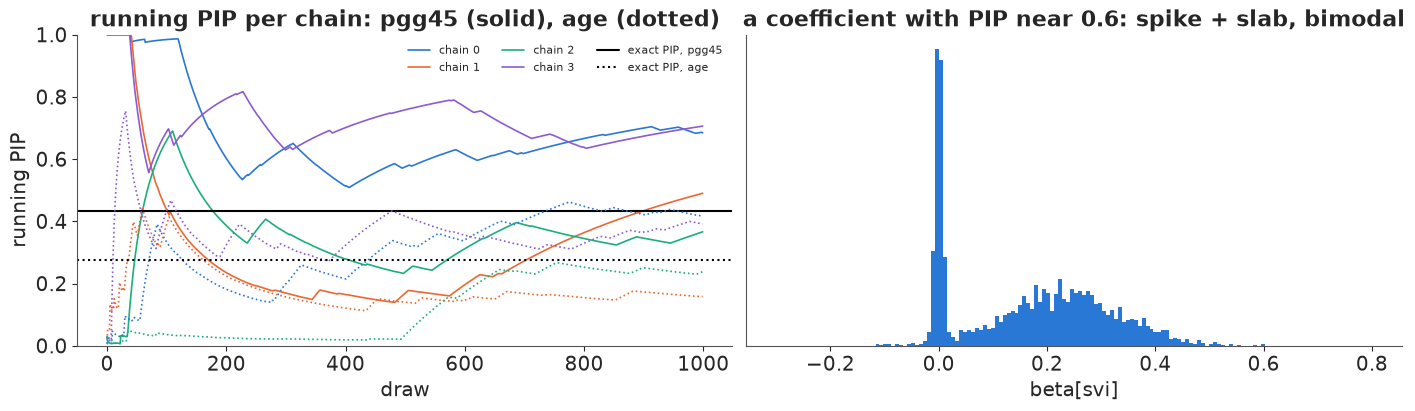

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
for name, ls in [("pgg45", "-"), ("age", ":")]:
    j = PR_NAMES.index(name)
    run = np.cumsum(pip_draws[:, j].reshape(4, -1), axis=1) / np.arange(1, pip_draws.shape[0] // 4 + 1)
    for c in range(4):
        ax.plot(run[c], lw=1.2, ls=ls, color=[BLUE, ORANGE, AQUA, PURPLE][c], label=f"chain {c}" if ls == "-" else None)
    ax.axhline(pip_exact[j], color="k", lw=1.5, ls=ls, label=f"exact PIP, {name}")
ax.set(xlabel="draw", ylabel="running PIP", ylim=(0, 1), title="running PIP per chain: pgg45 (solid), age (dotted)")
ax.legend(fontsize=8, ncol=3)
ax = axes[1]
ax.hist(draws(idata_ss_pr, "beta")[:, PR_NAMES.index("svi")], bins=150, range=(-0.3, 0.8), color=BLUE)
ax.set(xlabel="beta[svi]", yticks=[], title="a coefficient with PIP near 0.6: spike + slab, bimodal");

The left panel shows why. A running PIP that moves in long straight stretches is a chain that
sits in the spike (or the slab) for hundreds of draws before switching: each chain makes only
a handful of crossings, so four chains of 1000 draws amount to a few dozen independent
"decisions" per coefficient. The right panel is the posterior of `svi`: a needle at zero, a
slab around 0.2-0.3, and a thin valley between them that a gradient-based sampler has to
cross. A wider spike makes the valley shallower but then "excluded" no longer means "zero";
a narrower spike makes the valley deeper.

What NUTS **can** do with a spike-and-slab: sample the continuous relaxation, with the
indicators summed out one at a time, and produce Rao-Blackwellised PIPs that are right to
within Monte Carlo error that r_hat honestly reports as large. What it **cannot** do: the
point-mass version (a discrete model space), or mix well between "in" and "out". For small
$P$ enumerate, as above; for larger $P$ the standard tool is a Gibbs sampler over $\gamma$ with
the coefficients integrated out conjugately - not something PyMC's samplers provide.

## 5 · Diabetes: 64 candidate predictors, 120 patients

The LARS diabetes data (Efron et al. 2004) has ten baseline measurements on 442 patients and
a measure of disease progression a year later. Efron et al.'s "quadratic model" adds all 45
pairwise interactions and 9 squares (sex is binary, so no square), for **64 candidate
predictors**. We build those columns ourselves, fit on a random 120 patients (so $P = 64$ is
about half of $n$: least squares is possible but wild) and keep the other 322 as a test set.

In [10]:
data.describe("diabetes")
db = data.load("diabetes")
MAIN = ["age", "sex", "bmi", "bp", "tc", "ldl", "hdl", "tch", "ltg", "glu"]
db.columns = MAIN + ["y"]
perm = rng.permutation(len(db))
tr, te = perm[:120], perm[120:]
Zm = (db[MAIN] - db[MAIN].iloc[tr].mean()) / db[MAIN].iloc[tr].std()
cols64 = {m: Zm[m] for m in MAIN}
cols64 |= {f"{a}:{b}": Zm[a] * Zm[b] for a, b in itertools.combinations(MAIN, 2)}
cols64 |= {f"{m}^2": Zm[m] ** 2 for m in MAIN if m != "sex"}
X64 = pd.DataFrame(cols64)
NAMES = X64.columns.tolist()
X64 = ((X64 - X64.iloc[tr].mean()) / X64.iloc[tr].std()).to_numpy()
yd_mu, yd_sd = db["y"].iloc[tr].mean(), db["y"].iloc[tr].std()
yd = ((db["y"] - yd_mu) / yd_sd).to_numpy()
Xd_tr, yd_tr, Xd_te, yd_te = X64[tr], yd[tr], X64[te], yd[te]
n_d, P_d = Xd_tr.shape
C = np.corrcoef(Xd_tr.T)
iu = np.triu_indices(P_d, 1)
print(f"{n_d} training / {len(te)} test patients, {P_d} predictors")
print(f"pairs with |correlation| > 0.8: {(np.abs(C[iu]) > 0.8).sum()}, > 0.5: {(np.abs(C[iu]) > 0.5).sum()}")
for k in np.argsort(-np.abs(C[iu]))[:5]:
    print(f"  {NAMES[iu[0][k]]:>8} ~ {NAMES[iu[1][k]]:<8} r = {C[iu][k]:+.2f}")

diabetes: 442 diabetes patients: AGE, SEX, BMI, blood pressure BP, six blood serum measurements S1-S6 (S1 total cholesterol, S2 LDL, S3 HDL, S4 total/HDL ratio, S5 log triglycerides, S6 glucose) and Y, a measure of disease progression one year after baseline (raw, unstandardised).
  source: Efron, Hastie, Johnstone & Tibshirani (2004, Ann. Statist. 32:407), 'Least angle regression'; the LARS diabetes data.
  url:    https://web.stanford.edu/~hastie/Papers/LARS/diabetes.data
120 training / 322 test patients, 64 predictors
pairs with |correlation| > 0.8: 16, > 0.5: 104
    tc:ldl ~ ldl^2    r = +0.97
    tc:ldl ~ tc^2     r = +0.97
    age:tc ~ age:ldl  r = +0.95
    tc:tch ~ ldl:tch  r = +0.95
    bmi:tc ~ bmi:ldl  r = +0.95


This is a correlated design by construction: 16 pairs of columns correlate above 0.8 and
over a hundred above 0.5. The worst offenders all involve total cholesterol (`tc`) and LDL
(`ldl`), which correlate at 0.94 themselves, so every interaction built from one of them
nearly duplicates the matching interaction built from the other.

## 6 · Choosing the global scale: a prior guess $p_0$ and the prior on $m_\text{eff}$

With the horseshoe, $\tau$ is the knob that matters. The default $\tau \sim
\text{HalfCauchy}(1)$ is meant as "anything goes" on the scale of the data - we will see
that it is not. Piironen & Vehtari (2017) derive a better default: if you expect
about $p_0$ relevant predictors out of $P$, set

$$\tau_0 = \frac{p_0}{P - p_0}\,\frac{\sigma}{\sqrt n}, \qquad \tau \sim \text{HalfCauchy}(\tau_0).$$

The quantity that justifies this is the **effective number of non-zero coefficients**
$m_\text{eff} = \sum_j (1 - \kappa_j)$, the number of coefficients that escape shrinkage.
We should look at its *prior* before fitting anything - by simulation, because it has no
closed form. The guess here: $p_0 = 5$, a deliberately small number (a handful of the ten
baseline variables, few or none of the interactions).
The regularised horseshoe also has a **slab** $c$, which we come to in section 7.

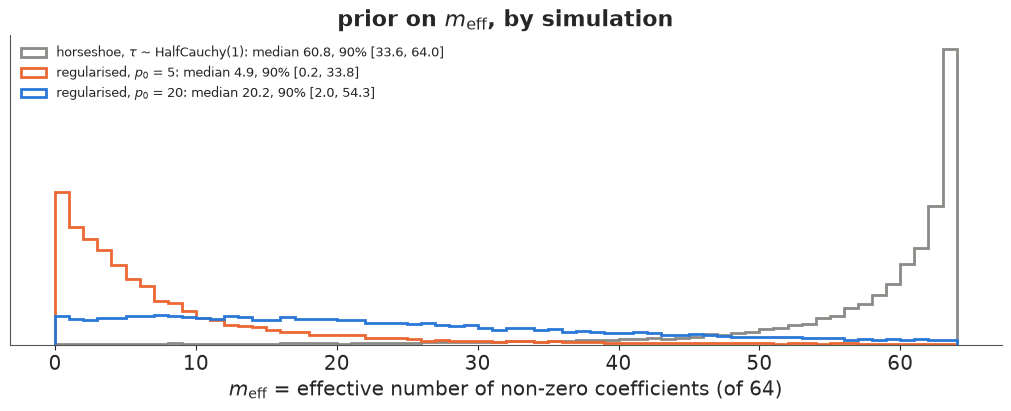

In [11]:
def m_eff_prior(n, P, S=20_000, tau0=None, slab=True, sigma_prior=True):
    """Simulate the prior of m_eff = sum_j (1 - kappa_j)."""
    sigma = np.abs(rng.normal(0, 1, S)) if sigma_prior else np.ones(S)
    lam = np.abs(stats.cauchy.rvs(size=(S, P), random_state=rng))
    if tau0 is None:  # plain horseshoe, tau ~ HalfCauchy(1) on the data scale
        tau = np.abs(stats.cauchy.rvs(size=S, random_state=rng))
    else:
        tau = np.abs(stats.cauchy.rvs(size=S, random_state=rng)) * tau0 * sigma
    if slab:
        c2 = stats.invgamma.rvs(2.0, scale=2.0, size=S, random_state=rng)
        lam = np.sqrt(c2[:, None] * lam**2 / (c2[:, None] + tau[:, None] ** 2 * lam**2))
    kappa = 1 / (1 + n * tau[:, None] ** 2 * lam**2 / sigma[:, None] ** 2)
    return (1 - kappa).sum(1)


def tau0_for(p0, P, n):
    return p0 / (P - p0) / np.sqrt(n)


meff = {
    r"horseshoe, $\tau$ ~ HalfCauchy(1)": m_eff_prior(n_d, P_d, slab=False),
    r"regularised, $p_0$ = 5": m_eff_prior(n_d, P_d, tau0=tau0_for(5, P_d, n_d)),
    r"regularised, $p_0$ = 20": m_eff_prior(n_d, P_d, tau0=tau0_for(20, P_d, n_d)),
}
fig, ax = plt.subplots(figsize=(10, 4))
for (name, m), col in zip(meff.items(), [GREY, ORANGE, BLUE]):
    ax.hist(m, bins=64, range=(0, 64), density=True, histtype="step", lw=2, color=col,
            label=f"{name}: median {np.median(m):.1f}, 90% [{np.quantile(m, 0.05):.1f}, {np.quantile(m, 0.95):.1f}]")
ax.set(xlabel=r"$m_\mathrm{eff}$ = effective number of non-zero coefficients (of 64)", yticks=[],
       title=r"prior on $m_\mathrm{eff}$, by simulation")
ax.legend(fontsize=9);

The default horseshoe, with $\tau \sim \text{HalfCauchy}(1)$, puts a prior median of **61
of 64** effective non-zero coefficients: "sparse prior" or not, at this global scale it says
that nearly everything matters, which is the opposite of what we believe. The
Piironen-Vehtari scale with $p_0 = 5$ puts the median at 5 with a long right tail (90%
interval 0.2 to 34), so the data can still ask for many more; $p_0 = 20$ is almost flat
over 0-50. $p_0$ is a soft guess, not a hard constraint - and this plot is how to check
that the prior you wrote says what you meant.

## 7 · The failure: a plain horseshoe diverges

First the textbook horseshoe with $\tau \sim \text{HalfCauchy}(1)$, written the obvious
(centred) way, $\beta_j \sim \text{Normal}(0, \tau\lambda_j)$, at the default
`target_accept=0.8`. Then the changes one at a time: non-centring, a higher
`target_accept`, the global scale $\tau_0$ from $p_0 = 5$ without a slab, and the full
regularised horseshoe ($p_0$ scale plus slab) at both `target_accept` values.

In [12]:
TAU0 = tau0_for(5, P_d, n_d)
variants = [
    ("horseshoe, centred, ta 0.8", dict(prior="horseshoe", centred=True), 0.8),
    ("horseshoe, non-centred, ta 0.8", dict(prior="horseshoe"), 0.8),
    ("horseshoe, non-centred, ta 0.99", dict(prior="horseshoe"), 0.99),
    ("p0-scaled horseshoe, no slab, ta 0.99", dict(prior="reg_horseshoe", tau0=TAU0, slab=False), 0.99),
    ("reg. horseshoe, non-centred, ta 0.8", dict(prior="reg_horseshoe", tau0=TAU0), 0.8),
    ("reg. horseshoe, non-centred, ta 0.99", dict(prior="reg_horseshoe", tau0=TAU0), 0.99),
]
fits_d, diag = {}, []
for label, kw, ta in variants:
    idata = fit(sparse_lm(Xd_tr, yd_tr, names=NAMES, **kw), label, target_accept=ta)
    s = az.summary(idata, var_names=["tau"])
    diag.append({"model": label, "divergences": int(idata.sample_stats["diverging"].sum()),
                 "mean tree depth": float(idata.sample_stats["depth"].mean()),
                 "tau r_hat": float(s["r_hat"].iloc[0]), "tau ess_bulk": float(s["ess_bulk"].iloc[0])})
    fits_d[label] = idata
pd.DataFrame(diag).set_index("model").round(2)

horseshoe, centred, ta 0.8               7.0 s  divergences  648  max r_hat 1.220  min ess_bulk    14


horseshoe, non-centred, ta 0.8           1.2 s  divergences  212  max r_hat 1.010  min ess_bulk   329


horseshoe, non-centred, ta 0.99          1.7 s  divergences   29  max r_hat 1.007  min ess_bulk   504


p0-scaled horseshoe, no slab, ta 0.99    1.8 s  divergences   18  max r_hat 1.004  min ess_bulk   431


reg. horseshoe, non-centred, ta 0.8      1.2 s  divergences  140  max r_hat 1.021  min ess_bulk   379


reg. horseshoe, non-centred, ta 0.99     1.9 s  divergences    1  max r_hat 1.003  min ess_bulk   550


,divergences,mean tree depth,tau r_hat,tau ess_bulk
model,,,,
"horseshoe, centred, ta 0.8",648,9.42,1.16,18.38
"horseshoe, non-centred, ta 0.8",212,4.90,1.01,328.73
"horseshoe, non-centred, ta 0.99",29,6.97,1.01,504.18
"p0-scaled horseshoe, no slab, ta 0.99",18,6.91,1.00,430.58
"reg. horseshoe, non-centred, ta 0.8",140,4.92,1.02,378.85
"reg. horseshoe, non-centred, ta 0.99",1,6.31,1.00,550.49


The pattern is typical of horseshoes:

- **Centred**: several hundred divergences, r_hat 1.2, ESS in the teens, and a mean tree
  depth above 9, close to nutpie's default cap of 10. Nothing from this fit can be used.
- **Non-centred** removes the worst of it - r_hat and ESS become respectable - but a couple of
  hundred divergences remain at the default `target_accept`.
- **`target_accept=0.99`** (smaller steps) brings them down to a few dozen; the $p_0$-based
  global scale alone to a similar number.
- The **regularised horseshoe** ($p_0$ scale *and* slab) with `target_accept=0.99` has 1
  divergence in 4000 draws, and at the default 0.8 it still has over a hundred. No single
  change is enough; the combination is.

The price is visible in the tree depth: 2-4 times more gradient evaluations per draw than
at 0.8. With 120 observations that is seconds.

Where do the divergences sit? In the centred model, the joint posterior of a null
coefficient and its scale is Neal's funnel: when $\tau\lambda_j$ is small, $\beta_j$ is
squeezed into a tiny interval, and a step size that works in the mouth of the funnel is far
too big in its neck.

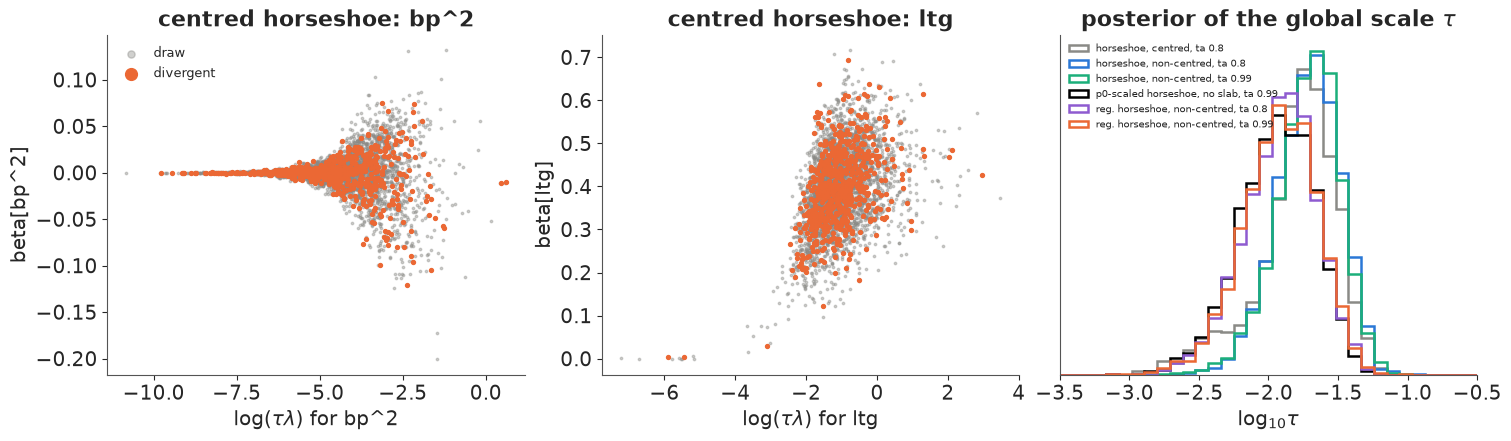

In [13]:
idc = fits_d["horseshoe, centred, ta 0.8"]
div = idc.sample_stats["diverging"].stack(sample=("chain", "draw")).to_numpy()
B_c = draws(idc, "beta")
scale = draws(idc, "tau")[:, None] * draws(idc, "lam")
j_null = int(np.argmin(np.abs(np.median(B_c, 0))))
j_big = NAMES.index("ltg")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, j in zip(axes[:2], [j_null, j_big]):
    ax.scatter(np.log(scale[~div, j]), B_c[~div, j], s=3, color=GREY, alpha=0.4, label="draw")
    ax.scatter(np.log(scale[div, j]), B_c[div, j], s=8, color=ORANGE, label="divergent")
    ax.set(xlabel=rf"log($\tau\lambda$) for {NAMES[j]}", ylabel=f"beta[{NAMES[j]}]",
           title=f"centred horseshoe: {NAMES[j]}")
axes[0].legend(fontsize=9, markerscale=3)
ax = axes[2]
for (label, idata), col in zip(fits_d.items(), [GREY, BLUE, AQUA, "k", PURPLE, ORANGE]):
    ax.hist(np.log10(draws(idata, "tau")), bins=60, range=(-5, 0.5), density=True, histtype="step", lw=1.8,
            color=col, label=label)
ax.set(xlabel=r"log$_{10}\tau$", yticks=[], xlim=(-3.5, -0.5), title=r"posterior of the global scale $\tau$")
ax.legend(fontsize=7, loc="upper left");

Left: the funnel for `bp^2`, a coefficient with nothing to say. As its scale $\tau\lambda_j$
shrinks, the coefficient is squeezed towards zero; the divergent draws (orange) are spread
along the mouth of the funnel and down its neck. Middle: `ltg`, a strong predictor, has no
funnel - the data pin it down - yet divergent draws show up there too, because a divergence
is a property of the whole trajectory in 64+ dimensions, not of one coordinate. Right: the
posterior of $\tau$ is much the same in every variant (the $p_0$-based ones sit a little
lower, as their prior asks). The fixes do not change the answer much; they change whether we
can **trust** it.

### What the slab changes

The plain horseshoe has Cauchy tails: a coefficient that the data only weakly identify (here,
a pair of highly correlated interactions) is allowed to wander to huge values, and the
sampler has to follow $\lambda_j$ out into those tails. The regularised horseshoe replaces
$\lambda_j$ by

$$\tilde\lambda_j = \sqrt{\frac{c^2\lambda_j^2}{c^2 + \tau^2\lambda_j^2}},$$

which behaves like $\lambda_j$ for small coefficients but caps the prior sd at $c$ for large
ones: a horseshoe near zero, a $\text{Normal}(0, c)$ slab far from it. With $c^2 \sim
\text{InvGamma}(2, 2)$ (a Student-$t_4$ slab with scale 1 on the standardised scale) no
coefficient can be larger than the data can support without paying for it.

In [14]:
idh, idr = fits_d["horseshoe, non-centred, ta 0.99"], fits_d["reg. horseshoe, non-centred, ta 0.99"]
Bh, Br = draws(idh, "beta"), draws(idr, "beta")
order = np.argsort(-np.abs(np.median(Br, 0)))[:12]
comp = pd.DataFrame({
    "horseshoe median": np.median(Bh, 0)[order], "horseshoe 1%": np.quantile(Bh, 0.01, 0)[order],
    "horseshoe 99%": np.quantile(Bh, 0.99, 0)[order], "reg. median": np.median(Br, 0)[order],
    "reg. 1%": np.quantile(Br, 0.01, 0)[order], "reg. 99%": np.quantile(Br, 0.99, 0)[order]},
    index=np.array(NAMES)[order])
print(f"largest |beta| in any draw: horseshoe {np.abs(Bh).max():.2f}, regularised {np.abs(Br).max():.2f}")
print(f"slab scale c: median {np.median(np.sqrt(draws(idr, 'c2'))):.2f}")
comp.round(2)

largest |beta| in any draw: horseshoe 0.76, regularised 0.78
slab scale c: median 1.04


,horseshoe median,horseshoe 1%,horseshoe 99%,reg. median,reg. 1%,reg. 99%
ltg,0.40,0.17,0.61,0.39,0.18,0.61
bmi,0.33,0.09,0.56,0.35,0.06,0.54
bp,0.11,-0.02,0.33,0.07,-0.02,0.33
age:sex,0.04,-0.03,0.25,0.02,-0.02,0.25
glu^2,0.03,-0.03,0.27,0.02,-0.03,0.29
tch:glu,0.01,-0.05,0.31,0.00,-0.04,0.26
tc:tch,-0.01,-0.33,0.06,-0.00,-0.30,0.05
ldl:glu,0.01,-0.06,0.27,0.00,-0.05,0.25
bp:tc,0.01,-0.05,0.22,0.00,-0.04,0.19
sex:bmi,0.01,-0.05,0.18,0.00,-0.04,0.17


The slab changes little in the estimates here: the medians and the 1-99% ranges agree to
within about 0.05, and the largest coefficient in any draw is about 0.8 under both. That is
expected - the slab only binds for coefficients comparable to $c$ (median about 1), and the
biggest effect here is 0.4. It earns its place in other problems: logistic regression with
(quasi-)separation, $p > n$ designs, or correlated groups where the Cauchy tails let a
weakly identified coefficient run off. The heavy left tails of `tc:tch` and `ldl:tch` in the
table (1% quantiles near -0.3 while their medians are 0) are a milder version of that: a
correlated pair whose credit the posterior cannot assign. Section 9 looks at them.

## 8 · Shrinkage profiles and inclusion probabilities

The posterior of $\kappa_j$ (computed draw by draw from $\tau$, $\tilde\lambda_j$ and $\sigma$)
says, per coefficient, how much the model shrinks it; the posterior of $m_\text{eff}$ is how
many coefficients it effectively uses.

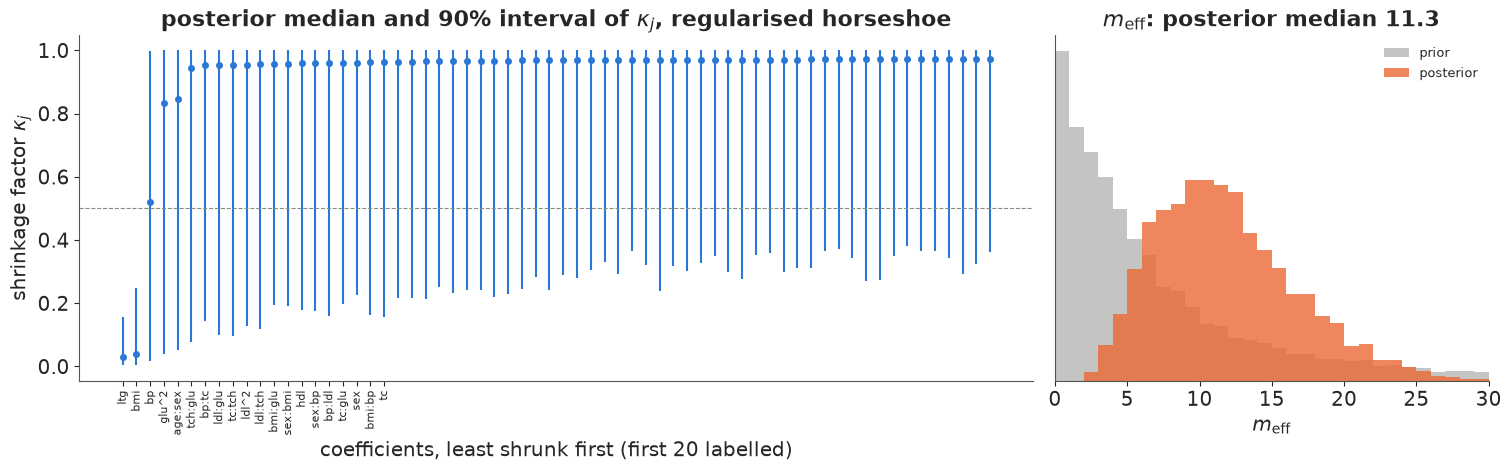

In [15]:
def kappa_draws(idata, n):
    tau, sigma, lam, c2 = (draws(idata, v) for v in ["tau", "sigma", "lam", "c2"])
    lt2 = c2[:, None] * lam**2 / (c2[:, None] + tau[:, None] ** 2 * lam**2)
    return 1 / (1 + n * tau[:, None] ** 2 * lt2 / sigma[:, None] ** 2)


K = kappa_draws(idr, n_d)
meff_post = (1 - K).sum(1)
order_k = np.argsort(np.median(K, 0))
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
lo, med, hi = np.quantile(K, [0.05, 0.5, 0.95], axis=0)
xs = np.arange(P_d)
ax.vlines(xs, lo[order_k], hi[order_k], color=BLUE, lw=1.5)
ax.plot(xs, med[order_k], "o", color=BLUE, ms=4)
ax.set_xticks(xs[:20])
ax.set_xticklabels(np.array(NAMES)[order_k][:20], rotation=90, fontsize=8)
ax.axhline(0.5, color=GREY, ls="--", lw=0.8)
ax.set(ylabel=r"shrinkage factor $\kappa_j$", xlabel="coefficients, least shrunk first (first 20 labelled)",
       title=r"posterior median and 90% interval of $\kappa_j$, regularised horseshoe")
ax = axes[1]
ax.hist(meff["regularised, $p_0$ = 5"], bins=64, range=(0, 64), density=True, color=GREY, alpha=0.5, label="prior")
ax.hist(meff_post, bins=64, range=(0, 64), density=True, color=ORANGE, alpha=0.8, label="posterior")
ax.set(xlabel=r"$m_\mathrm{eff}$", yticks=[], xlim=(0, 30),
       title=rf"$m_\mathrm{{eff}}$: posterior median {np.median(meff_post):.1f}")
ax.legend(fontsize=9);

Two coefficients escape shrinkage completely (`ltg` and `bmi`, $\kappa$ near 0). `bp` is
half-shrunk with an interval covering almost everything. `glu^2` and `age:sex` lean towards
shrinkage but with wide intervals; the remaining 59 have posterior median $\kappa$ around
0.94-0.97, but the lower ends of their intervals reach 0.1-0.4: in some draws each of them is
let through. That is why
$m_\text{eff}$ has a posterior median of about 11 although only two or three predictors
are clearly in: 60 coefficients that each keep a few per cent add up. (One caveat: the
$\kappa$ formula assumes roughly uncorrelated predictors, which this design is not; read it
as a shrinkage profile, not an exact decomposition.)

The horseshoe has no indicator, so it has no inclusion probability in the strict sense. The
spike-and-slab does: fit it on the 64 predictors (marginalised as in section 4) and compare
its PIPs with the horseshoe's $P(\kappa_j < 0.5)$, "the probability that the data outweigh
the prior for this coefficient", a common stand-in.

In [16]:
idata_ss_d = fit(spike_slab_model(Xd_tr, yd_tr, NAMES), "diabetes, spike-and-slab", target_accept=0.95)
pip_d_draws = pip_rao_blackwell(idata_ss_d)
pip_d = pip_d_draws.mean(0)
pip_d_chain = pip_d_draws.reshape(4, -1, P_d).mean(1)
p_k = (K < 0.5).mean(0)
print(f"horseshoe P(kappa < 0.5), all 64 coefficients: min {p_k.min():.2f}, "
      f"median {np.median(p_k):.2f}, 5th largest {np.sort(p_k)[-5]:.2f}")
top = np.argsort(-np.maximum(pip_d, p_k))[:14]
pd.DataFrame({"spike-slab PIP": pip_d[top], "PIP chain min": pip_d_chain.min(0)[top],
              "PIP chain max": pip_d_chain.max(0)[top], "reg. horseshoe P(kappa<0.5)": p_k[top],
              "reg. horseshoe median beta": np.median(Br, 0)[top]}, index=np.array(NAMES)[top]).round(2)

diabetes, spike-and-slab                 2.1 s  divergences    0  max r_hat 1.488  min ess_bulk     8
horseshoe P(kappa < 0.5), all 64 coefficients: min 0.07, median 0.10, 5th largest 0.32


,spike-slab PIP,PIP chain min,PIP chain max,reg. horseshoe P(kappa<0.5),reg. horseshoe median beta
ltg,1.00,1.00,1.00,1.00,0.39
bmi,0.99,0.97,1.00,0.99,0.35
bp,0.37,0.00,0.84,0.49,0.07
glu^2,0.01,0.00,0.03,0.34,0.02
ldl:glu,0.33,0.00,0.70,0.18,0.00
age:sex,0.08,0.00,0.21,0.32,0.02
tch:glu,0.02,0.00,0.07,0.21,0.00
tc:tch,0.05,0.00,0.13,0.20,-0.00
ldl:tch,0.16,0.00,0.62,0.17,-0.00
bp:tc,0.01,0.00,0.03,0.16,0.00


The diabetes spike-and-slab is the prostate problem made worse: zero divergences, but r_hat
far above 1.1, a single-digit bulk ESS, and per-chain PIPs that disagree wildly beyond the
two obvious predictors (look at the chain min / max columns: a chain that never includes a
variable next to one that includes it most of the time). With 64 indicators there is no
enumeration to fall back on either ($2^{64}$ models). All we can take from this fit is that
`ltg` and `bmi` are in; the other numbers in its first column are Monte Carlo noise.

The horseshoe's $P(\kappa_j < 0.5)$ comes from a fit that mixes well and tells a consistent
story: `ltg` and `bmi` near 1, `bp` about 0.5, `glu^2` and `age:sex` about a third, and 0.2 or
less for the rest, never 0. That is *not* a PIP (no coefficient is ever exactly zero under a
horseshoe), and the floor is the prior talking: its pole at $\kappa = 0$ keeps some mass on
"not shrunk" for every coefficient.

## 9 · Correlated predictors: how the posterior splits the credit

When two predictors carry nearly the same information, the likelihood pins down (roughly)
their *sum* and leaves their difference free; a sparse prior then prefers solutions in which
one of them does the work - but it does not know which one. In the diabetes data the
interactions `tc:tch` and `ldl:tch` correlate at 0.95 (total and LDL cholesterol, each times
the cholesterol ratio), and so do `tc` and `ldl` themselves at 0.94. We use the regularised
horseshoe, whose sampling we trust, and call a coefficient "relevant" in a draw when
$|\beta_j| > 0.05$ (a twentieth of an sd of the outcome per sd of the predictor).

 tc:tch / ldl:tch: P(first relevant) 0.20, P(second) 0.17, P(at least one) 0.34, P(both) 0.03; posterior correlation of the two betas -0.17
     tc / ldl    : P(first relevant) 0.13, P(second) 0.10, P(at least one) 0.22, P(both) 0.01; posterior correlation of the two betas -0.18
prostate, exact: gleason / pgg45: P(first) 0.25, P(second) 0.43, P(at least one) 0.53, P(both) 0.16
prostate, exact: svi / lcp: P(first) 0.63, P(second) 0.36, P(at least one) 0.68, P(both) 0.31


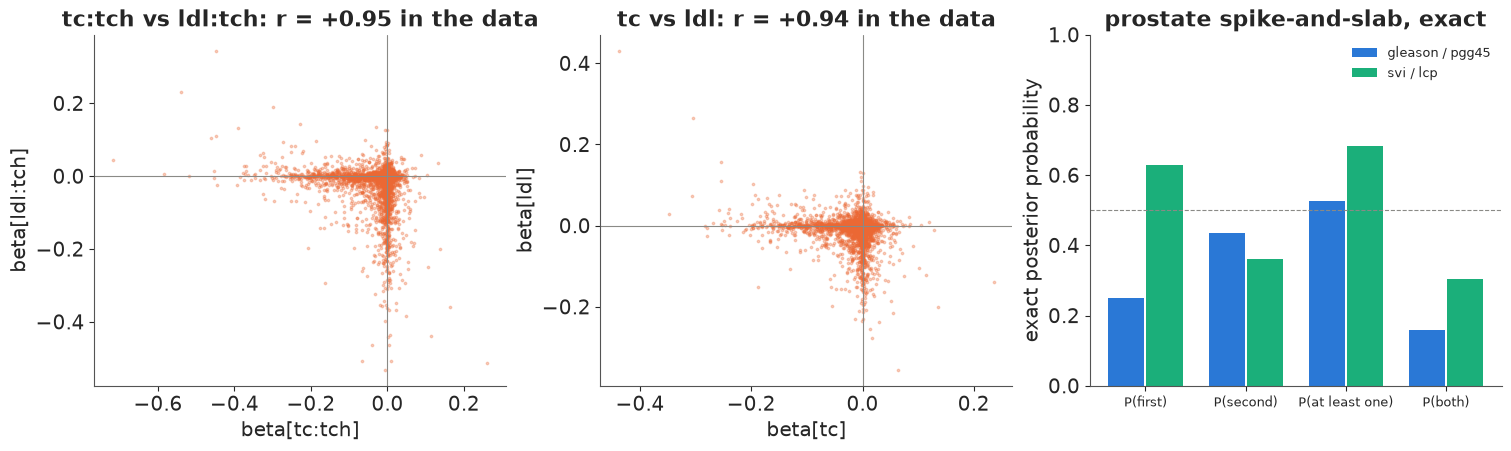

In [17]:
DELTA = 0.05
pairs = [("tc:tch", "ldl:tch"), ("tc", "ldl")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
rows = []
for ax, (u, v) in zip(axes[:2], pairs):
    iu_, iv_ = NAMES.index(u), NAMES.index(v)
    ru, rv = np.abs(Br[:, iu_]) > DELTA, np.abs(Br[:, iv_]) > DELTA
    rows.append((f"{u} / {v}", ru.mean(), rv.mean(), (ru | rv).mean(), (ru & rv).mean()))
    ax.scatter(Br[:, iu_], Br[:, iv_], s=3, color=ORANGE, alpha=0.3)
    ax.axhline(0, color=GREY, lw=0.8)
    ax.axvline(0, color=GREY, lw=0.8)
    ax.set(xlabel=f"beta[{u}]", ylabel=f"beta[{v}]", title=f"{u} vs {v}: r = {C[iu_, iv_]:+.2f} in the data")
    print(f"{u:>7} / {v:<7}: P(first relevant) {rows[-1][1]:.2f}, P(second) {rows[-1][2]:.2f}, "
          f"P(at least one) {rows[-1][3]:.2f}, P(both) {rows[-1][4]:.2f}; "
          f"posterior correlation of the two betas {np.corrcoef(Br[:, iu_], Br[:, iv_])[0, 1]:+.2f}")

# the same question answered exactly: prostate, all 256 models enumerated (section 4)
ax = axes[2]
lab = ["P(first)", "P(second)", "P(at least one)", "P(both)"]
for k, (u, v) in enumerate([("gleason", "pgg45"), ("svi", "lcp")]):
    gu, gv = MODELS[:, PR_NAMES.index(u)], MODELS[:, PR_NAMES.index(v)]
    vals = [w_models @ gu, w_models @ gv, w_models @ (gu | gv), w_models @ (gu & gv)]
    ax.bar(np.arange(4) + 0.38 * k, vals, width=0.36, color=[BLUE, AQUA][k], label=f"{u} / {v}")
    print(f"prostate, exact: {u} / {v}: " + ", ".join(f"{l} {x:.2f}" for l, x in zip(lab, vals)))
ax.axhline(0.5, color=GREY, ls="--", lw=0.8)
ax.set_xticks(np.arange(4) + 0.19)
ax.set_xticklabels(lab, fontsize=9)
ax.set(ylim=(0, 1), ylabel="exact posterior probability", title="prostate spike-and-slab, exact")
ax.legend(fontsize=9);

The two scatter plots are the signature of a sparse prior meeting a correlated pair: the mass
lies along the **axes** - one coefficient non-zero, the other at zero - and almost never in the
quadrant where both are. Each member of `tc:tch` / `ldl:tch` is "relevant" in about one draw
in five, the pair in about one in three, both together almost never. A table of marginal
probabilities (0.20 and 0.17) makes the pair look weaker than it is (0.34). And the ordinary posterior
correlation of the two coefficients is only about -0.2: the dependence is a cross, not an
ellipse, and a correlation coefficient does not see it.

The right panel asks the same question of the exact prostate posterior. Both Gleason
variables have PIP below 0.5 (0.25 and 0.43), so the usual "median probability model" (keep
everything with PIP above 0.5) drops both - yet the posterior probability that *at least
one* of them belongs in the model is 0.53. The lesson is general: with correlated predictors,
ask about **groups** (at least one of this cluster), or use a selection method that looks at
predictions rather than at coefficients one at a time.

## 10 · From a posterior to a choice of variables: projection predictive selection

Thresholding marginal PIPs is the obvious rule, and section 9 shows why it can drop both
members of a pair that matters. **Projection predictive** selection (Goutis & Robert 1998;
Piironen, Paasiniemi & Vehtari 2020; the `projpred` R package, `kulprit` in Python) takes a
different route: fit the best model you can - the *reference model*, here the regularised
horseshoe on all 64 predictors - and then look for the smallest submodel whose predictions
are close to the reference model's.

For a Gaussian linear model the projection is ordinary least squares. For each posterior
draw $s$ the reference model's fitted means $\mu^{(s)}$ are regressed on the submodel's
columns; the projected noise is $\sigma_\perp^{(s)2} = \sigma^{(s)2} + \|\mu^{(s)} - X_S
\beta_\perp^{(s)}\|^2/n$. A forward search adds, at each step, the predictor that makes the
projection closest to the reference. `kulprit` is not installed here, so we write it - it is
25 lines of NumPy. The search uses the training data only; the held-out patients are used to
score each submodel size.

In [18]:
def gauss_elpd(y, mu, sigma):
    """Pointwise log predictive density, averaged over draws: mu (S, n), sigma (S,)."""
    lp = stats.norm.logpdf(y[None, :], mu, sigma[:, None])
    return logsumexp(lp, axis=0) - np.log(len(sigma))


def project(X, Mu, sigma, cols):
    """Project every draw's fitted mean onto the columns `cols` (plus intercept)."""
    Xs_ = np.c_[np.ones(len(X)), X[:, cols]]
    coef, *_ = np.linalg.lstsq(Xs_, Mu.T, rcond=None)                       # (k+1, S)
    resid = Mu - (Xs_ @ coef).T
    return coef, np.sqrt(sigma**2 + (resid**2).mean(1))


def forward_search(X, Mu, sigma, max_size):
    path = []
    for _ in range(max_size):
        best, best_d = None, np.inf
        for j in set(range(X.shape[1])) - set(path):
            coef, _ = project(X, Mu, sigma, path + [j])
            d = ((Mu - (np.c_[np.ones(len(X)), X[:, path + [j]]] @ coef).T) ** 2).sum()
            if d < best_d:
                best, best_d = j, d
        path.append(best)
    return path


thin = slice(None, None, 4)                                               # 1000 draws are plenty
a_r, s_r, B_r = draws(idr, "a")[thin], draws(idr, "sigma")[thin], Br[thin]
Mu_tr = a_r[:, None] + B_r @ Xd_tr.T
MAX_SIZE = 15
path = forward_search(Xd_tr, Mu_tr, s_r, MAX_SIZE)
elpd_ref = gauss_elpd(yd_te, a_r[:, None] + B_r @ Xd_te.T, s_r)
sizes, elpd_k, se_k = [0] + list(range(1, MAX_SIZE + 1)), [], []
for k in sizes:
    coef, s_perp = project(Xd_tr, Mu_tr, s_r, path[:k])
    mu_te = (np.c_[np.ones(len(Xd_te)), Xd_te[:, path[:k]]] @ coef).T
    e = gauss_elpd(yd_te, mu_te, s_perp)
    elpd_k.append(e.sum())
    se_k.append(np.sqrt(len(e)) * np.std(e - elpd_ref))
elpd_k, se_k = np.array(elpd_k), np.array(se_k)
size_sel = int(np.argmax(elpd_k - elpd_ref.sum() > -se_k))
print("search path:", ", ".join(NAMES[j] for j in path))
print(f"size 0 (intercept only): {elpd_k[0] - elpd_ref.sum():.0f} below the reference")
print(f"smallest size within one SE of the reference: {size_sel} -> {[NAMES[j] for j in path[:size_sel]]}")

search path: bmi, ltg, glu^2, bp, age:sex, ldl:tch, tch:glu, bp:tc, bmi^2, hdl, ldl:glu, tc, sex:bp, sex:tch, tc:hdl
size 0 (intercept only): -104 below the reference
smallest size within one SE of the reference: 4 -> ['bmi', 'ltg', 'glu^2', 'bp']


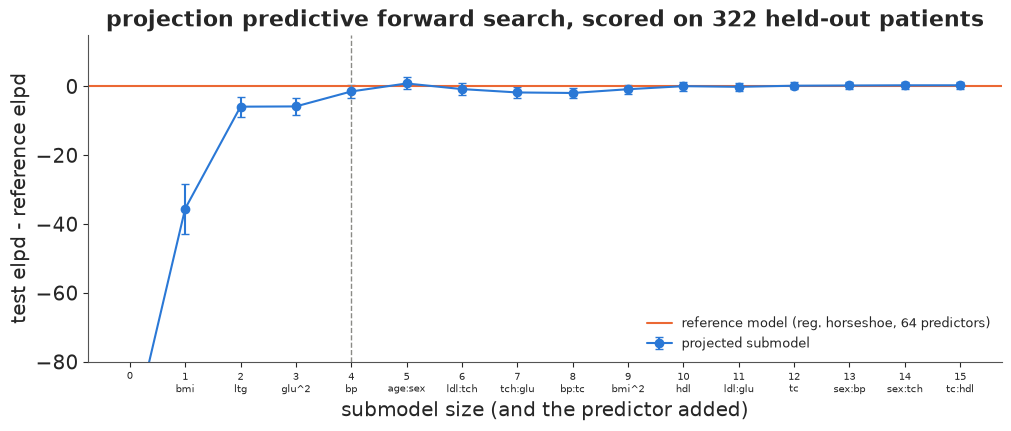

In [19]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.errorbar(sizes, elpd_k - elpd_ref.sum(), yerr=se_k, fmt="o-", color=BLUE, capsize=3,
            label="projected submodel")
ax.axhline(0, color=ORANGE, lw=1.5, label="reference model (reg. horseshoe, 64 predictors)")
ax.axvline(size_sel, color=GREY, ls="--", lw=1)
ax.set_xticks(sizes)
ax.set_xticklabels([f"{k}\n{NAMES[path[k - 1]]}" if k else "0" for k in sizes], fontsize=7)
ax.set(ylabel="test elpd - reference elpd", xlabel="submodel size (and the predictor added)",
       ylim=(max(-80, (elpd_k - elpd_ref.sum()).min() - 10), 15),
       title="projection predictive forward search, scored on 322 held-out patients")
ax.legend(fontsize=9, loc="lower right");

The intercept-only model is more than 100 elpd units behind the reference. Adding the
predictors in the order the search found them - `bmi` and `ltg` first, then `glu^2` and `bp`
- closes almost all of the gap: with those four the projected model is within one standard
error of the full 64-predictor reference, and from five on the curve stays within about 2
elpd of it. The four chosen predictors are body-mass index, blood pressure, log
triglycerides and squared glucose - the last one ranked fourth by the horseshoe's
$P(\kappa < 0.5)$ and missed entirely by the (badly mixed) spike-and-slab.

Two honest caveats. (1) We chose the size by looking at the *test* set; `projpred` does it
by cross-validation on the training data (with the search repeated inside each fold, since a
search that saw the data is optimistic), which is the right way when there is no spare test
set. (2) Forward search is greedy, and with correlated predictors the order among the
near-duplicates is somewhat arbitrary - but projection solves the problem of section 9: a
submodel that contains `tc:tch` does not need `ldl:tch`, and the search knows that because it
measures predictions, not coefficients.

## 11 · The frequentist reference: lasso with cross-validation

Coordinate descent for the lasso is a dozen lines: cycle through the coefficients,
soft-threshold each partial residual correlation, repeat until nothing moves. A path of 50
penalties from the one that zeroes everything down to 1% of it, with warm starts and 10-fold
cross-validation, takes a few seconds. (Going further down the path is slow and pointless
here: with 64 collinear columns and 108 rows per fold, coordinate descent crawls when the
penalty is tiny, and cross-validation has long stopped improving.)

In [20]:
def lasso_cd(X, y, lam, b=None, tol=1e-6, max_iter=5000):
    """Coordinate descent on the Gram matrix for (1/2n)||y - Xb||^2 + lam ||b||_1."""
    n, P = X.shape
    G, c = X.T @ X / n, X.T @ y / n
    b = np.zeros(P) if b is None else b.copy()
    Gb = G @ b
    for _ in range(max_iter):
        delta = 0.0
        for j in range(P):
            old = b[j]
            rho = c[j] - Gb[j] + G[j, j] * old                  # partial-residual correlation
            new = np.sign(rho) * max(abs(rho) - lam, 0.0) / G[j, j]
            if new != old:
                Gb += G[:, j] * (new - old)
                b[j] = new
                delta = max(delta, abs(new - old))
        if delta < tol:
            break
    return b


def lasso_path(X, y, lams):
    xm, ym = X.mean(0), y.mean()
    b, out = None, []
    for lam in lams:
        b = lasso_cd(X - xm, y - ym, lam, b)
        out.append((ym - xm @ b, b.copy()))
    return out


t0 = time.time()
lam_max = np.abs(Xd_tr.T @ (yd_tr - yd_tr.mean())).max() / n_d
lams = lam_max * np.logspace(0, -2, 50)
folds = rng.permutation(n_d) % 10
cv = np.zeros((10, len(lams)))
for f in range(10):
    fit_path = lasso_path(Xd_tr[folds != f], yd_tr[folds != f], lams)
    for k, (a0, b) in enumerate(fit_path):
        cv[f, k] = np.mean((yd_tr[folds == f] - a0 - Xd_tr[folds == f] @ b) ** 2)
cv_mean, cv_se = cv.mean(0), cv.std(0) / np.sqrt(10)
k_min = int(np.argmin(cv_mean))
k_1se = int(np.argmax(cv_mean <= cv_mean[k_min] + cv_se[k_min]))
full_path = lasso_path(Xd_tr, yd_tr, lams)
lasso_min, lasso_1se = full_path[k_min], full_path[k_1se]
print(f"lasso path + 10-fold CV: {time.time() - t0:.1f} s; lambda_min is penalty {k_min + 1} of {len(lams)}, "
      f"lambda_1se is {k_1se + 1}")
for label, (a0, b) in [("lambda_min", lasso_min), ("lambda_1se", lasso_1se)]:
    nz = np.flatnonzero(b)
    print(f"lasso {label}: {len(nz)} non-zero: {', '.join(NAMES[j] for j in nz[np.argsort(-np.abs(b[nz]))])}")

lasso path + 10-fold CV: 4.3 s; lambda_min is penalty 20 of 50, lambda_1se is 13
lasso lambda_min: 8 non-zero: ltg, bmi, bp, glu^2, age:sex, hdl, bmi^2, tc:tch
lasso lambda_1se: 4 non-zero: ltg, bmi, bp, glu^2


At the penalty that minimises cross-validated error ($\lambda_\text{min}$) the lasso keeps
8 predictors; at the largest penalty within one standard error of that minimum
($\lambda_\text{1se}$, the usual "sparser but as good" rule) it keeps 4 - `ltg`, `bmi`,
`bp` and `glu^2`, the **same four** that the projection chose. Two quite different routes to
the same answer is reassuring. The lasso gives no uncertainty about that choice, though; the
posterior does (the size-by-size curve above, and the $\kappa$ intervals).

## 12 · Held-out predictive performance

Finally, the question that does not depend on anyone's definition of "selected": how well
does each fit predict the 322 patients it has not seen? We report the root mean squared
error of the posterior mean prediction and the log predictive density (elpd) in the original
units of the progress score. For least squares and the lasso the elpd is a plug-in Normal
with the training residual sd (so it ignores estimation uncertainty and flatters them a
little).

In [21]:
fits_d["ridge"] = fit(sparse_lm(Xd_tr, yd_tr, "ridge", NAMES), "ridge", target_accept=0.9)
fits_d["Bayesian lasso"] = fit(sparse_lm(Xd_tr, yd_tr, "lasso", NAMES), "Bayesian lasso", target_accept=0.9)


def score_bayes(a, B, sigma, X, y):
    """Test RMSE (original units) and pointwise test log predictive density (original units)."""
    mu = a[:, None] + B @ X.T
    rmse = np.sqrt(np.mean((mu.mean(0) - y) ** 2)) * yd_sd
    return rmse, gauss_elpd(y, mu, sigma) - np.log(yd_sd)


def score_plugin(a0, b, X_tr, y_tr, X, y):
    resid_sd = np.std(y_tr - a0 - X_tr @ b)
    mu = a0 + X @ b
    rmse = np.sqrt(np.mean((mu - y) ** 2)) * yd_sd
    return rmse, stats.norm.logpdf(y, mu, resid_sd) - np.log(yd_sd)


rows = {}
coef_ols = np.linalg.lstsq(np.c_[np.ones(n_d), Xd_tr], yd_tr, rcond=None)[0]
rows["least squares, 64 predictors"] = score_plugin(coef_ols[0], coef_ols[1:], Xd_tr, yd_tr, Xd_te, yd_te)
coef_10 = np.linalg.lstsq(np.c_[np.ones(n_d), Xd_tr[:, :10]], yd_tr, rcond=None)[0]
rows["least squares, 10 main effects"] = score_plugin(coef_10[0], coef_10[1:], Xd_tr[:, :10], yd_tr, Xd_te[:, :10], yd_te)
rows["lasso, lambda_min"] = score_plugin(*lasso_min, Xd_tr, yd_tr, Xd_te, yd_te)
rows["lasso, lambda_1se"] = score_plugin(*lasso_1se, Xd_tr, yd_tr, Xd_te, yd_te)
for label in ["ridge", "Bayesian lasso", "horseshoe, non-centred, ta 0.99", "reg. horseshoe, non-centred, ta 0.99"]:
    i = fits_d[label]
    rows[label] = score_bayes(draws(i, "a"), draws(i, "beta"), draws(i, "sigma"), Xd_te, yd_te)
rows["spike-and-slab"] = score_bayes(draws(idata_ss_d, "a"), draws(idata_ss_d, "beta"), draws(idata_ss_d, "sigma"),
                                     Xd_te, yd_te)
coef, s_perp = project(Xd_tr, Mu_tr, s_r, path[:size_sel])
rows[f"projection, {size_sel} predictors"] = score_bayes(
    coef[0], coef[1:].T, s_perp, Xd_te[:, path[:size_sel]], yd_te)
ref_pw = rows["reg. horseshoe, non-centred, ta 0.99"][1]
res = pd.DataFrame({label: {"test RMSE": r, "test elpd": pw.sum(), "elpd - reg. horseshoe": (pw - ref_pw).sum(),
                            "SE of difference": np.sqrt(len(pw)) * np.std(pw - ref_pw)}
                    for label, (r, pw) in rows.items()}).T
print("main effects, least squares (10 predictors) vs reg. horseshoe median (64 predictors):")
print(pd.DataFrame({"least squares": coef_10[1:], "reg. horseshoe": np.median(Br[:, :10], 0)}, index=MAIN).round(2).T)
res.round(1)

ridge                                    0.8 s  divergences    0  max r_hat 1.003  min ess_bulk  1582


Bayesian lasso                           1.0 s  divergences    0  max r_hat 1.004  min ess_bulk   946
main effects, least squares (10 predictors) vs reg. horseshoe median (64 predictors):
                 age   sex   bmi    bp    tc   ldl   hdl   tch   ltg   glu
least squares  -0.01 -0.14  0.33  0.21 -0.75  0.39  0.27  0.26  0.58  0.06
reg. horseshoe  0.00 -0.00  0.35  0.07 -0.00 -0.00 -0.00  0.00  0.39  0.00


,test RMSE,test elpd,elpd - reg. horseshoe,SE of difference
"least squares, 64 predictors",137.1,-4080.2,-2331.3,717.4
"least squares, 10 main effects",54.0,-1741.7,7.1,5.9
"lasso, lambda_min",54.0,-1741.8,7.1,2.7
"lasso, lambda_1se",56.3,-1757.2,-8.3,4.3
ridge,56.8,-1762.4,-13.6,4.6
Bayesian lasso,55.6,-1755.4,-6.6,3.1
"horseshoe, non-centred, ta 0.99",54.6,-1749.5,-0.6,0.7
"reg. horseshoe, non-centred, ta 0.99",54.4,-1748.9,0.0,0.0
spike-and-slab,55.0,-1751.5,-2.6,2.0
"projection, 4 predictors",54.7,-1750.3,-1.5,2.1


What the table says, in order of confidence:

- **Least squares with 64 predictors** is a disaster (RMSE 137 on an outcome whose sd is
  about 77): this is the problem that shrinkage solves. Every shrinkage method gets to an
  RMSE of 54-57.
- The **horseshoes beat ridge** clearly (about 14 elpd, about 3 standard errors) and the
  Bayesian lasso by about 2 standard errors. Plain and regularised horseshoe predict the
  same, and the projected 4-predictor submodel loses only 1.5 (SE 2). The lasso at
  $\lambda_\text{1se}$ has the *same four* predictors but loses about 8: its penalty shrinks
  the four coefficients that it keeps, while the projection fits them to the reference
  model's predictions without further shrinkage.
- The **surprise**: the lasso at $\lambda_\text{min}$ and plain least squares on the 10 main
  effects are *better* than the regularised horseshoe, by about 7 elpd (0.02 per patient;
  RMSE 54.0 against 54.4). For the lasso the difference is about 2.5 standard errors, so it
  is probably not noise; for the main-effects model it is only 1.2. (The plug-in elpd
  flatters the two point estimates somewhat, so the real gap is a little smaller.) The printed main effects show the likely reason. Least squares on the
  10 main effects uses a **contrast** of the correlated cholesterol measurements (`tc` -0.75,
  `ldl` +0.39, `hdl` +0.27, `tch` +0.26) plus `sex` and a larger `bp`; the horseshoe sets
  all the cholesterol terms and `sex` to zero and keeps `bp` at a third of the size. A
  contrast of correlated predictors is exactly what a sparse prior finds expensive (section
  9): several non-zero coefficients where one would almost do. On 120 patients the data are
  not strong enough to overrule $p_0 = 5$. The horseshoe is not automatically the best
  predictor; it is a good default when you believe in sparsity, and a held-out set (or LOO)
  is how you find out whether you should.
- The spike-and-slab predicts about as well as the others despite its sampling problems:
  prediction averages over the confusion about *which* correlated variable is in, which
  matters little for $\hat y$. Its PIPs, not its predictions, are what the poor mixing ruins.

## 13 · Summary

| Question | Answer in this notebook |
|---|---|
| Why not a Normal prior? | It shrinks every coefficient by the same factor ($\kappa$ fixed): noise is kept and signal is shrunk |
| Is the Bayesian lasso sparse? | Its *mode* is (that is the lasso); its posterior is not - no pole at zero, and one rate for noise and signal |
| What makes the horseshoe work? | A U-shaped prior on $\kappa$: each coefficient is either shrunk away or left alone |
| How to set $\tau$? | From a guess $p_0$: $\tau_0 = \frac{p_0}{P-p_0}\frac{\sigma}{\sqrt n}$; check the implied prior on $m_\text{eff}$ by simulation. HalfCauchy(1) says "almost everything is non-zero" |
| Divergences? | Non-centre, raise `target_accept`, use the regularised horseshoe (scale + slab): all three together took ~650 to 1 |
| Spike-and-slab with NUTS? | Only the continuous relaxation, indicators summed out one at a time; no divergences but poor mixing between in and out - check r_hat per chain, enumerate when $P$ is small |
| Correlated predictors? | The posterior splits the credit along the axes; marginal inclusion probabilities undercount a correlated pair - ask about groups |
| Which variables? | Projection predictive selection: smallest submodel whose predictions match the reference. Here `bmi`, `ltg`, `bp`, `glu^2` - as the lasso at $\lambda_\text{1se}$ |
| Does it predict better? | Much better than least squares and ridge; not better than the CV lasso or a main-effects model on this split - check, do not assume |

## Try it yourself

1. **p > n.** Refit sections 7-12 on 50 training patients instead of 120 (so $P = 64 > n$).
   Least squares is no longer defined; which of the priors degrade gracefully, and does the
   projection still find `ltg`, `bmi` and `bp` first?
2. **Sensitivity to $p_0$.** Refit the regularised horseshoe with $p_0 = 1$ and $p_0 = 20$ and
   overlay the posteriors of $m_\text{eff}$ on their priors. How much does the posterior move
   with the prior guess on 120 patients - and on all 442?
3. **A real high-dimensional problem.** The riboflavin data (Bühlmann, Kalisch & Meier 2014;
   R package `hdi`) has $n = 71$ and $P = 4088$ gene expressions. Screen to the 500 genes
   most correlated with the response (and say why screening on the training data biases what
   follows), fit the regularised horseshoe with $p_0 = 10$, and compare the projection path
   with the lasso's.